In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [5]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.backends.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [6]:
# Ensure the project root is in the Python path for module imports
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from cd_poly.cd_poly import *
from simulation.gen_pend import *

In [7]:
param_dists = {
    'q': stats.uniform(-np.pi, 2 * np.pi),
    'v': stats.norm(loc=0, scale=1),
    'b': stats.uniform(loc=0, scale=0.01)
}

times, trajs = gen_trajs(10_000, 3., 128, param_dists)

In [8]:
trajs.shape

(10000, 2, 128)

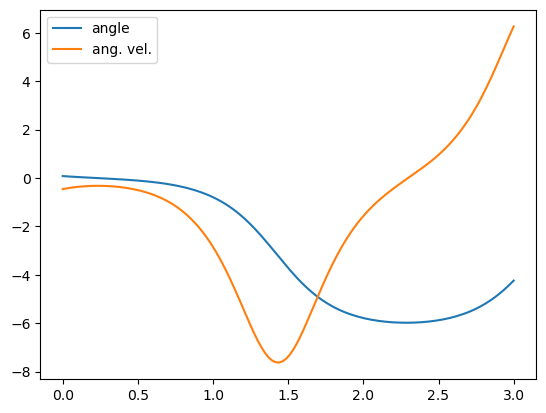

In [9]:
i = np.random.randint(10_000)
plt.plot(times, trajs[i, 0], label='angle');
plt.plot(times, trajs[i, 1], label='ang. vel.')
plt.legend();

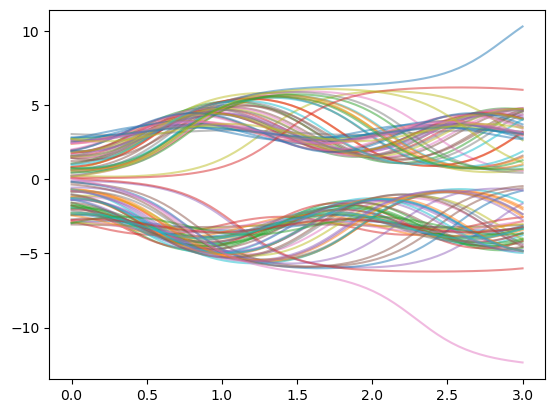

In [10]:
for i in range(100):
    plt.plot(times, trajs[i, 0], alpha=.5)

In [11]:
def to_sincos(trajs):
    sincos = np.concatenate((np.sin(trajs[:, :1]),
                             np.cos(trajs[:, :1])),
                             axis=1)
    return np.concatenate((sincos, trajs[:, 1:]), axis=1)

trajs = to_sincos(trajs)

In [12]:
trajs.shape

(10000, 3, 128)

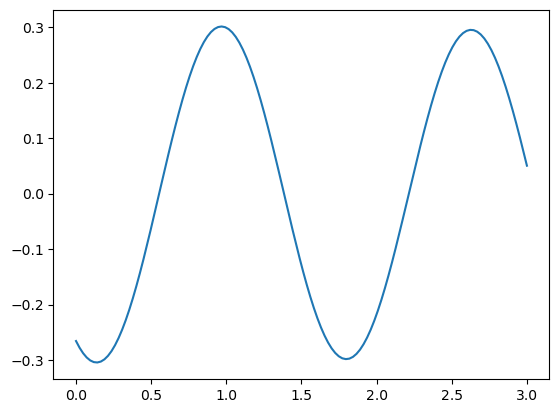

In [13]:
plt.plot(times, trajs[100, 0])

## 1D Conv

In [14]:
X_tr, X_val = random_split(torch.tensor(trajs[:, :1]), (0.6, 0.4))
dl_tr = DataLoader(X_tr, batch_size=256, shuffle=True)
dl_val = DataLoader(X_val, batch_size=256, shuffle=True)

In [15]:
class Conv1DAutoencoder(nn.Module):
    def __init__(self, chan, length, n_layers, n_latents):
        super(Conv1DAutoencoder, self).__init__()

        self.convs = nn.Sequential()
        in_channel = chan
        for i in range(n_layers):  # each layer doubles number of channels and halves input length
            out_channel = 2 * in_channel
            layer = [
                nn.Conv1d(in_channels=in_channel, out_channels=out_channel, kernel_size=3, stride=2, padding=1),
                nn.BatchNorm1d(out_channel),
            ]
            if i < n_layers - 1: # only add ReLU if it's not the last layer
                layer.append(nn.ReLU(inplace=True))

            self.convs.append(
                nn.Sequential(*layer)
            )
            in_channel *= 2
        self.enc_fc = nn.Linear(chan * length, n_latents)

        self.dec_fc = nn.Linear(n_latents, chan * length)
        self.input_channel = chan * 2 ** n_layers

        self.deconvs = nn.Sequential()
        in_channel = self.input_channel
        for i in range(n_layers):  # each layer halves number of channels and doubles input length
            out_channel = in_channel // 2
            layer = [
                nn.ConvTranspose1d(in_channels=in_channel, out_channels=out_channel, kernel_size=3, stride=2, padding=1, output_padding=1),
                nn.BatchNorm1d(out_channel),
            ]
            if i < n_layers - 1: # only add ReLU if it's not the last layer
                layer.append(nn.ReLU(inplace=True))

            self.deconvs.append(
                nn.Sequential(*layer)
            )
            in_channel //= 2

    def forward(self, x):
        enc = self.enc_fc(self.convs(x).view(x.size(0), -1))
        rec = self.dec_fc(enc).view(x.size(0), self.input_channel, -1)
        rec = self.deconvs(rec)

        return rec, enc

## Training

In [10]:
model = Conv1DAutoencoder(1, 128, 3, 10).to(device)

opt = optim.Adam(model.parameters(), lr=2e-3)
loss_fn = nn.MSELoss()

print(f'# params: {sum(p.numel() for p in model.parameters())}')

# params: 3013


In [263]:
n_epochs = 100

train_losses = []
val_losses = []

for epoch in range(n_epochs):
    # --- Training ---
    model.train()
    train_loss = 0.0
    
    for batch_idx, x in enumerate(dl_tr):
        x = x.to(device)

        opt.zero_grad()
        rec, lat = model(x)
        loss = loss_fn(rec, x) # avg over batch
        loss.backward()
        opt.step()

        train_loss += loss.item() * x.size(0)

    avg_train_loss = train_loss / len(dl_tr.dataset)
    train_losses.append(train_loss)

    # --- Validation ---
    model.eval()
    val_loss = 0.0

    for batch_idx, x in enumerate(dl_val):
        x = x.to(device)

        rec, lat = model(x)
        loss = loss_fn(rec, x)
        val_loss += loss.item() * x.size(0)

    avg_val_loss = val_loss / len(dl_val.dataset)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}], Tr Loss: {train_loss:.4f} Val Loss: {val_loss:.4f}")

Epoch [10/100], Tr Loss: 588.1333 Val Loss: 373.7786
Epoch [20/100], Tr Loss: 325.4854 Val Loss: 217.1795
Epoch [30/100], Tr Loss: 260.7805 Val Loss: 185.4484
Epoch [40/100], Tr Loss: 227.3849 Val Loss: 157.9433
Epoch [50/100], Tr Loss: 203.2590 Val Loss: 142.9322
Epoch [60/100], Tr Loss: 181.6850 Val Loss: 126.9048
Epoch [70/100], Tr Loss: 171.7994 Val Loss: 119.2063
Epoch [80/100], Tr Loss: 154.7974 Val Loss: 113.9120
Epoch [90/100], Tr Loss: 148.1608 Val Loss: 109.4059
Epoch [100/100], Tr Loss: 140.6734 Val Loss: 106.9521


In [19]:
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.yscale('log')
plt.legend()

NameError: name 'train_losses' is not defined

## Tests

In [ ]:
PATH = './1d_conv_5latents_state_dict.pth'
if not os.path.exists(PATH):
    torch.save(model.state_dict(), PATH)
    print(f"Model saved to '{PATH}'")
else:
    print(f"Model already exists at '{PATH}'; not overwriting.")

Model already exists at './1d_conv_5latents_state_dict.pth'; not overwriting.


In [16]:
model = Conv1DAutoencoder(1, 128, 3, 10).to(device)
PATH = './1d_conv_10latents_state_dict.pth'
model.load_state_dict(torch.load(PATH))

<All keys matched successfully>

In [17]:
model.to("cpu")
with torch.no_grad():
    _, latents = model(torch.tensor(trajs[:, :1]))

## Plotting some latents

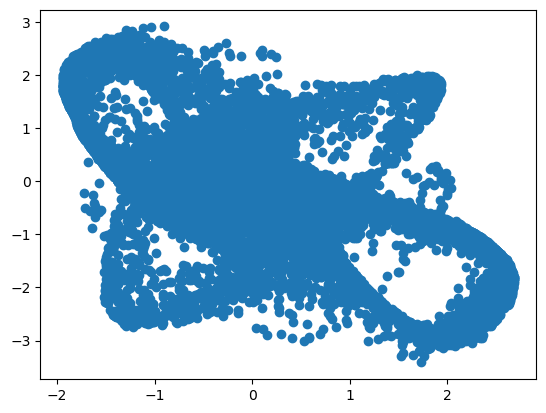

In [26]:
plt.scatter(*latents[:, 6:8].T)

In [76]:
def plot_most_similar(latents, pt, num, ax):
    "Plot the trajectories that have the num closest latents to pt."
    dists = np.linalg.norm(latents - pt, axis=1)
    closest_idxs = np.argsort(dists)[:num]
    for idx in closest_idxs:
        ax.plot(times, trajs[idx, 0, :], alpha=.3)

/var/folders/c2/vhmqh4t566q95zcjystvh20c0000gn/T/ipykernel_8450/4048237539.py:3: DeprecationWarning:

__array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)



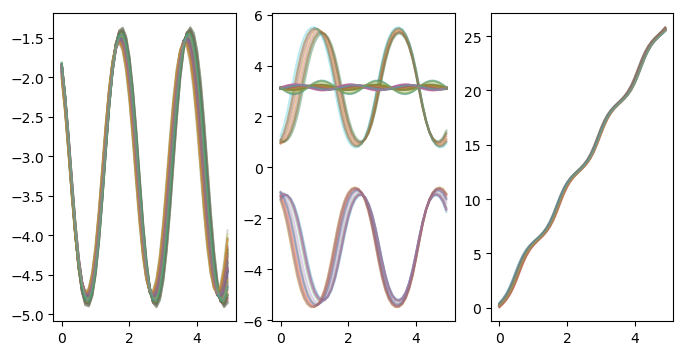

In [77]:
fig, axs = plt.subplots(1, 3, figsize=(8, 4))
plot_most_similar(latents, np.array([-10, -10]), 100, axs[0])
plot_most_similar(latents, np.array([0, 0]), 100, axs[1])
plot_most_similar(latents, np.array([30, 20]), 50, axs[2])

In [24]:
from latent_app import create_dash_app

In [26]:
app = create_dash_app(latents.numpy(), trajs[:, 0])
app.run()

## Testing trajectories outside of the training distribution

In [32]:
_, traj_ood = gen_one_traj(5., 50, np.pi/4, 10., 3.)

with torch.no_grad():
    _, latents_ood = model(torch.tensor(traj_ood))
latents_ood

tensor([[-2.8979,  3.5439]])

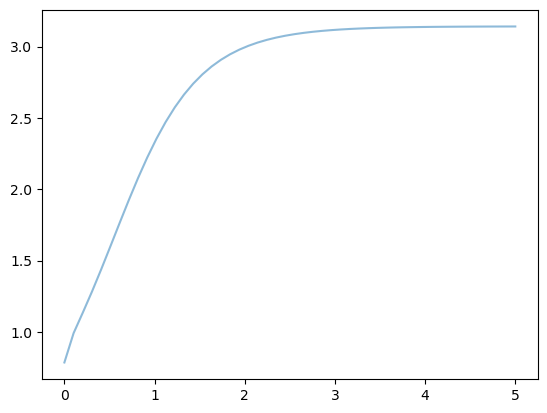

In [33]:
plt.plot(times, traj_ood[0, 0], alpha=.5)

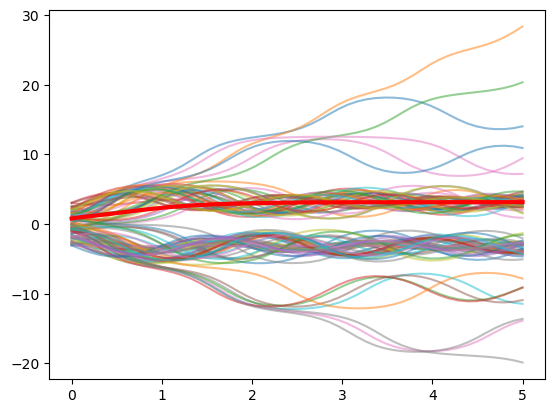

In [34]:
for i in range(100):
    plt.plot(times, trajs[i, 0], alpha=.5)
plt.plot(times, traj_ood[0, 0], color='red', lw=3)

## Using CD poly

In [36]:
p = CDPolynomial(latents, degree=6)
alpha = p(latents).max()

In [37]:
alpha

np.float64(6525.232838208118)

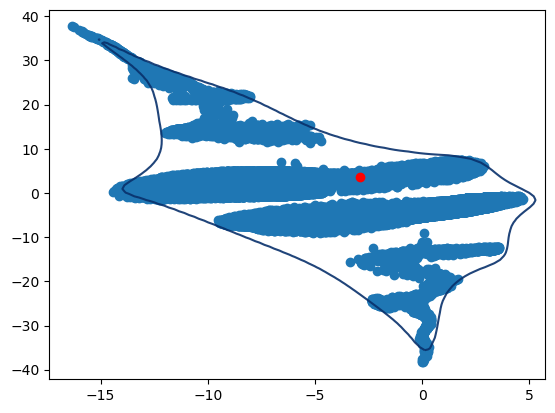

In [38]:
fig, ax = plt.subplots()
ax.scatter(*latents.numpy().T)
ax.scatter(*latents_ood.T, color='red')
plot_level_set(p, alpha / 10, ax)

## Testing custom trajectories

Let's create a custom trajectory that couldn't be generated by the simulation with our distribution of parameters.

In [39]:
amp = 1.5
freq = 13.
const = 4
custom = np.array([amp * np.sin(freq * times) + const * times, amp * freq * np.cos(freq * times) + const])

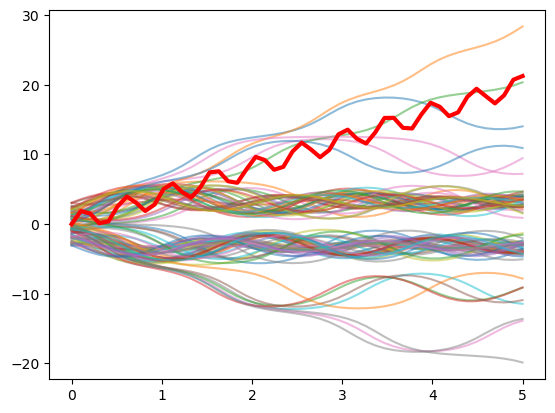

In [40]:
for i in range(100):
    plt.plot(times, trajs[i, 0], alpha=.5)
plt.plot(times, custom[0], color='red', lw=3)

In [41]:
with torch.no_grad():
    _, latents_custom = model(torch.tensor(custom.reshape(1, 2, -1)))
latents_custom

tensor([[-23.8442,  15.3420]])

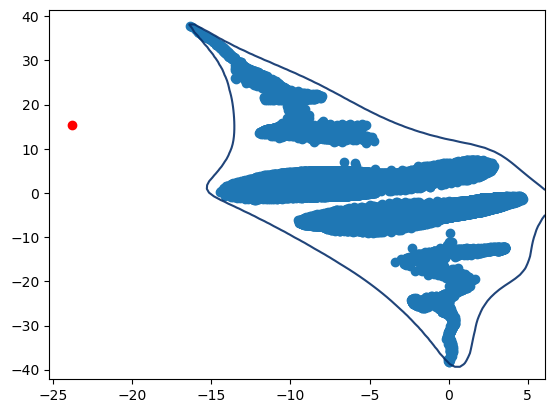

In [42]:
fig, ax = plt.subplots()
ax.scatter(*latents.numpy().T)
ax.scatter(*latents_custom.T, color='red')
plot_level_set(p, alpha, ax)

## OOD detection experiments

In [18]:
import seaborn as sns
import pandas as pd

In [19]:
param_dists_ood = param_dists.copy()
param_dists_ood['b'] = stats.uniform(1., 0.)
_, trajs_ood = gen_trajs(1000, 3., 128, param_dists_ood)
trajs_ood = to_sincos(trajs_ood)
trajs_ood.shape

(1000, 3, 128)

In [20]:
with torch.no_grad():
    rec_ood, lat_ood = model(torch.Tensor(trajs_ood[:, :1]))

lat_ood = lat_ood.numpy()

In [21]:
p = CDPolynomial(latents, degree=3)

In [22]:
(p(lat_ood) > p.mean).mean()

np.float64(0.99)

In [23]:
if latents.shape[1] == 2:
    plt.scatter(*latents.T)
    plt.scatter(*lat_ood.T)
    p.plot(plt.gca())

In [24]:
time = 3.
n_sim = 5

bs = np.linspace(0., .3, 11)
ls = np.linspace(.9, 1.1, 11)

data = []

p = CDPolynomial(latents, degree=3)

for b_idx, b in enumerate(bs):
    for l_idx, l in enumerate(ls):
        param_dists_ood = param_dists.copy()
        param_dists_ood['b'] = stats.uniform(b, 0.)
        _, trajs_ood = gen_trajs(1000, time, 128, param_dists_ood, length=l)
        trajs_ood = to_sincos(trajs_ood)

        with torch.no_grad():
            rec_ood, lat_ood = model(torch.Tensor(trajs_ood[:, :1]))
        lat_ood = lat_ood.numpy()

        acc = (p(lat_ood) > p.mean).mean()
        data.append({'b': b, 'l': l, 'acc': acc})
    print(f'Done with b = {b}.')

df = pd.DataFrame(data)

Done with b = 0.0.
Done with b = 0.03.
Done with b = 0.06.
Done with b = 0.09.
Done with b = 0.12.
Done with b = 0.15.
Done with b = 0.18.
Done with b = 0.21.
Done with b = 0.24.
Done with b = 0.27.
Done with b = 0.3.


In [ ]:
#df.to_csv('ae_acc.csv')
#df = pd.read_csv('ae_acc.csv')

Text(0.5, 1.0, 'Accuracy for different lengths')

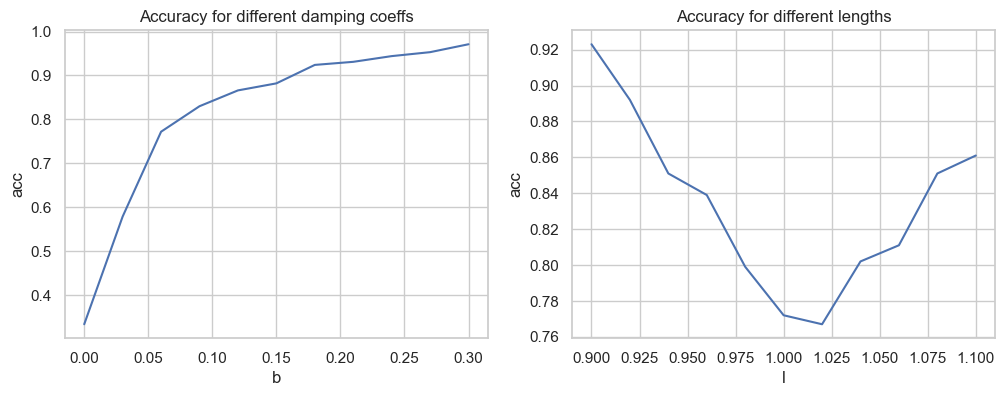

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.set_theme(style="whitegrid")

sns.lineplot(df[df['l'] == 1.0], x='b', y='acc', ax=ax[0])
ax[0].set_title('Accuracy for different damping coeffs')

sns.lineplot(df[df['b'] == .06], x='l', y='acc', ax=ax[1])
ax[1].set_title('Accuracy for different lengths')

Text(0.5, 0.92, 'Accuracy surface for AE')

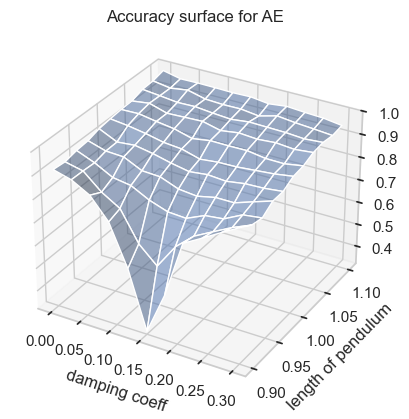

In [33]:
X, Y = np.meshgrid(bs, ls)
Z = df.iloc[:, -1].to_numpy().reshape(11, 11)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, alpha=.5)
ax.set_xlabel('damping coeff')
ax.set_ylabel('length of pendulum')
ax.set_title('Accuracy surface for AE')